In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as ns

In [2]:
df = pd.read_csv("D:\Shivudu\Time Series\AirPassengers.csv")
df

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\LuxLogix Design PC 2\AppData\Local\Temp\ipykernel_22340\360208593.py:1: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("D:\Shivudu\Time Series\AirPassengers.csv")


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [3]:
df.isnull().sum()

Month          0
#Passengers    0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [7]:
df['Month'] = pd.to_datetime(df['Month'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [10]:
df.set_index('Month', inplace=True)

In [11]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


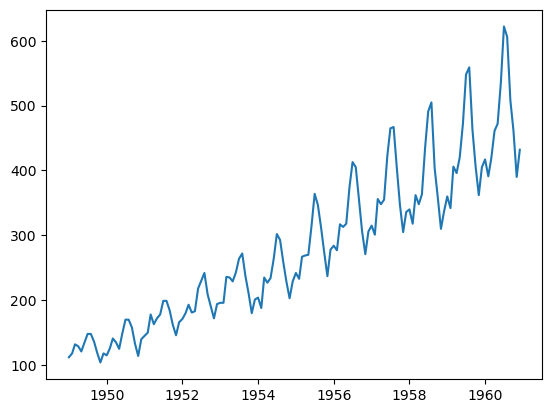

In [12]:
plt.plot(df)

from the graph we can observe that there is a upward trend and sesonality in data, so we can say data is non-stationary

mean and standard devaiation are fluctuating

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

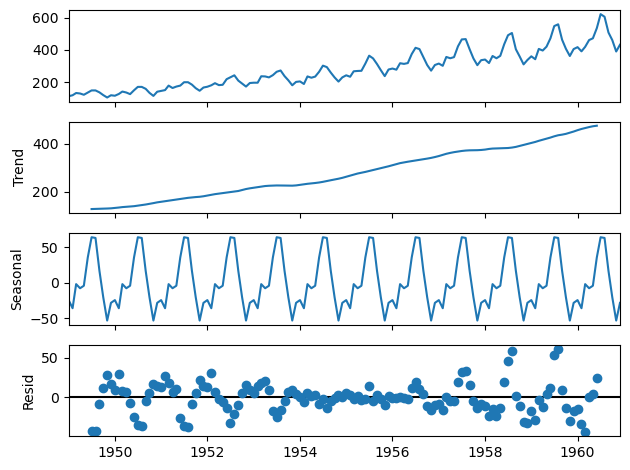

In [20]:
seasonal_decompose(df).plot();

to Prove statistaclly we use ADFuller Test

In [22]:
from statsmodels.tsa.stattools import adfuller

In [24]:
result = adfuller(df)
result

(0.8153688792060597,
 0.9918802434376411,
 13,
 130,
 {'1%': -3.4816817173418295,
  '5%': -2.8840418343195267,
  '10%': -2.578770059171598},
 996.692930839019)

In [25]:
#stats_value, P_value, Lags, Observations

In [27]:
p_value = result[1]
p_value

0.9918802434376411

In [29]:
if p_value<0.05:
    print('The data is Stationary')
else:
    print('The data is Non-Stationary')
    

The data is Non-Stationary


In [33]:
#To check whether mean and standard Deviation are fluctuating

rolling_mean = df.rolling(window=12).mean()

rolling_std = df.rolling(window=12).std()

In [34]:
rolling_mean.head(20)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


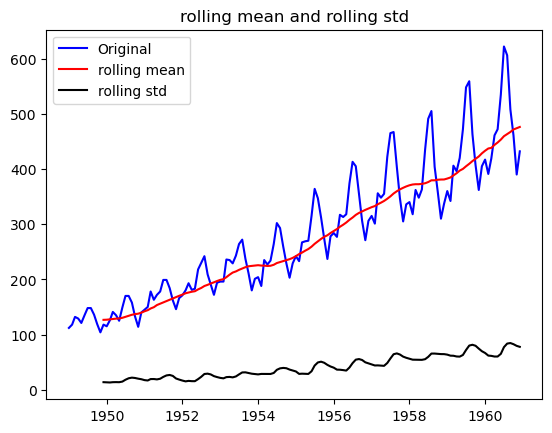

In [40]:
plt.plot(df, color ='blue', label ='Original')
plt.plot(rolling_mean , color ='red', label ='rolling mean')
plt.plot(rolling_std, color ='black',label='rolling std')
plt.legend(loc ='best')
plt.title('rolling mean and rolling std')
plt.show()

we see Mean and std are not constant they are incresing/varying so dat is non stationary

### Log Transformation

detrending the data/Smoothening the data by using logarithmic transformation

In [42]:
log_df = np.log(df)

In [43]:
log_df

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


In [44]:
rolling_mean1 = log_df.rolling(window=12).mean()

rolling_std1 = log_df.rolling(window=12).std()

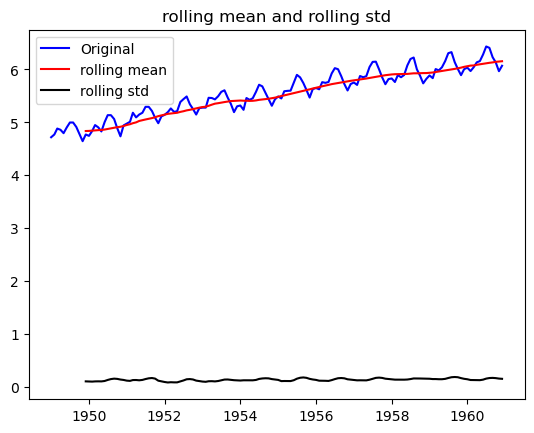

In [45]:
plt.plot(log_df, color ='blue', label ='Original')
plt.plot(rolling_mean1 , color ='red', label ='rolling mean')
plt.plot(rolling_std1, color ='black',label='rolling std')
plt.legend(loc ='best')
plt.title('rolling mean and rolling std')
plt.show()

In [46]:
#Differencing

diff_data = log_df.diff()

In [49]:
diff_df = diff_data
diff_df

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,0.052186
1949-03-01,0.112117
1949-04-01,-0.022990
1949-05-01,-0.064022
...,...
1960-08-01,-0.026060
1960-09-01,-0.176399
1960-10-01,-0.097083


In [50]:
rolling_mean2 = diff_df.rolling(window=12).mean()

rolling_std2 = diff_df.rolling(window=12).std()

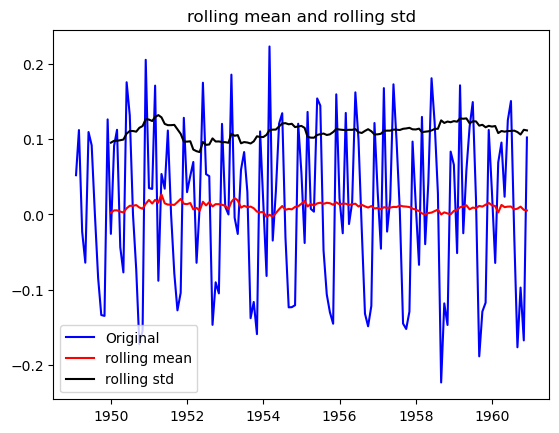

In [51]:
plt.plot(diff_df, color ='blue', label ='Original')
plt.plot(rolling_mean2 , color ='red', label ='rolling mean')
plt.plot(rolling_std2, color ='black',label='rolling std')
plt.legend(loc ='best')
plt.title('rolling mean and rolling std')
plt.show()

In [54]:
diff_df.dropna(inplace=True)

In [55]:
result1 = adfuller(diff_df)
result1

(-2.7171305983881675,
 0.07112054815085295,
 14,
 128,
 {'1%': -3.4825006939887997,
  '5%': -2.884397984161377,
  '10%': -2.578960197753906},
 -440.35846985568105)

In [56]:
p_value1 = result1[1]

In [57]:
if p_value<0.05:
    print('The data is Stationary')
else:
    print('The data is Non-Stationary')
   

The data is Non-Stationary


In [58]:
#Model Implementation of Time Series Model

In [59]:
#Total 144 rows out of which im considering 120 rows in training set and 24 rows in test set

train = log_df.iloc[: 120, :]

test = log_df.iloc[120: , :] #2 years

In [60]:
train

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1958-08-01,6.224558
1958-09-01,6.001415
1958-10-01,5.883322


In [61]:
test

,#Passengers
Month,
1959-01-01,5.886104
1959-02-01,5.834811
1959-03-01,6.006353
1959-04-01,5.981414
1959-05-01,6.040255
1959-06-01,6.156979
1959-07-01,6.306275
1959-08-01,6.326149
1959-09-01,6.137727


In [62]:
#Model Building of ARIMA Model

from statsmodels.tsa.arima.model import ARIMA

In [63]:
ARIMA_model = ARIMA(train, order=(2,1,2)) #p,d,q

C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [64]:
arima_model = ARIMA_model.fit()

In [65]:
log_df['ARIMA Prediction'] = arima_model.predict(start = len(train), end = len(train)+len(test)-1)

In [69]:
log_df[120:]

,#Passengers,ARIMA Prediction
Month,,
1959-01-01,5.886104,5.909270
1959-02-01,5.834811,5.887463
1959-03-01,6.006353,5.903143
1959-04-01,5.981414,5.901953
1959-05-01,6.040255,5.905386
1959-06-01,6.156979,5.905979
1959-07-01,6.306275,5.906949
1959-08-01,6.326149,5.907338
1959-09-01,6.137727,5.907669


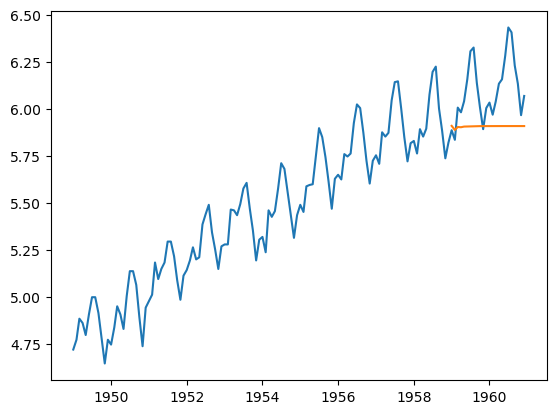

In [70]:
plt.plot(log_df)

To get optimal P and Q values we can the below

1. ACF and PACF plot --> Not recommended

2. itertools --> performing the model with various combinations manually

In [73]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

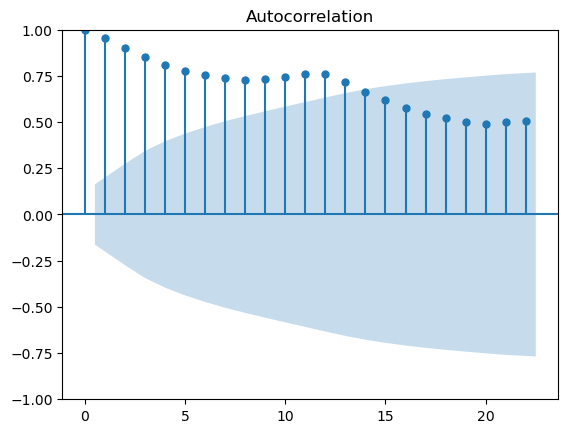

In [76]:
plot_acf(log_df['#Passengers']);

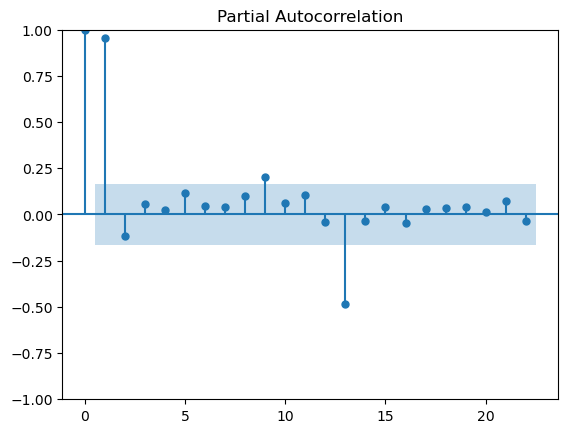

In [77]:
plot_pacf(log_df['#Passengers']);

from above two graphs we can assume as below

from plot 1 q = 14

from plot 2 p = 3

In [79]:
ARIMA_model1 = ARIMA(train, order=(3,1,14)) #p,d,q


C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [80]:
arima_model1 = ARIMA_model1.fit()

C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [91]:
log_df['ARIMA Prediction'] = arima_model1.predict(start = len(train), end = len(train)+len(test)-1)

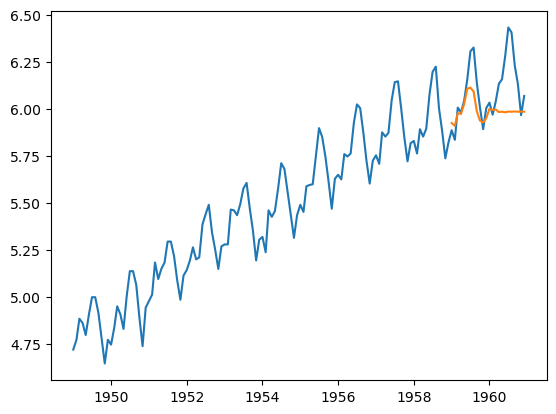

In [92]:
plt.plot(log_df)

In [95]:
#itertools

import itertools

p = range(1,8)
d = range(1,2)
q = range(1,8)

pdq_combinations = list(itertools.product(p,d,q))
pdq_combinations

[(1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 1, 4),
 (1, 1, 5),
 (1, 1, 6),
 (1, 1, 7),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 1, 4),
 (2, 1, 5),
 (2, 1, 6),
 (2, 1, 7),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3),
 (3, 1, 4),
 (3, 1, 5),
 (3, 1, 6),
 (3, 1, 7),
 (4, 1, 1),
 (4, 1, 2),
 (4, 1, 3),
 (4, 1, 4),
 (4, 1, 5),
 (4, 1, 6),
 (4, 1, 7),
 (5, 1, 1),
 (5, 1, 2),
 (5, 1, 3),
 (5, 1, 4),
 (5, 1, 5),
 (5, 1, 6),
 (5, 1, 7),
 (6, 1, 1),
 (6, 1, 2),
 (6, 1, 3),
 (6, 1, 4),
 (6, 1, 5),
 (6, 1, 6),
 (6, 1, 7),
 (7, 1, 1),
 (7, 1, 2),
 (7, 1, 3),
 (7, 1, 4),
 (7, 1, 5),
 (7, 1, 6),
 (7, 1, 7)]

In [96]:
from sklearn.metrics import mean_squared_error

rmse = []
orders1 = []

for pdq in pdq_combinations:
    model = ARIMA(train, order = pdq)
    model_fit = model.fit()
    pred = model_fit.predict(start = len(train), end = len(train)+len(test)-1)
    error = np.sqrt(mean_squared_error(test, pred))
    orders1.append(pdq)
    rmse.append(error)

C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No fr

In [98]:
result = pd.DataFrame(index = orders1, data  = rmse, columns=['RMSE'])

In [99]:
result.sort_values(by ='RMSE') # ascending

,RMSE
"(5, 1, 4)",0.149964
"(6, 1, 4)",0.159458
"(7, 1, 7)",0.161576
"(7, 1, 5)",0.172065
"(7, 1, 4)",0.178406
"(7, 1, 2)",0.187929
"(3, 1, 3)",0.188723
"(5, 1, 5)",0.193352
"(4, 1, 4)",0.193900
"(6, 1, 5)",0.194336


In [100]:
ARIMA_model = ARIMA(train, order=(5,1,4))
arima_model = ARIMA_model.fit()

C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [102]:
log_df['ARIMA Pridiction'] = arima_model.predict(start = len(train) , end = len(train)+len(test)-1)

In [103]:
log_df[120:]

,#Passengers,ARIMA Prediction,ARIMA Pridiction
Month,,,
1959-01-01,5.886104,5.924368,5.811950
1959-02-01,5.834811,5.909112,5.861380
1959-03-01,6.006353,5.977127,5.969164
1959-04-01,5.981414,5.972435,6.051946
1959-05-01,6.040255,6.024420,6.122208
1959-06-01,6.156979,6.107536,6.176193
1959-07-01,6.306275,6.112837,6.153700
1959-08-01,6.326149,6.091765,6.098807
1959-09-01,6.137727,5.987035,6.033715


In [105]:
log_df.drop(['ARIMA Pridiction'], axis=1, inplace= True)

In [106]:
log_df['ARIMA Prediction'] = arima_model.predict(start = len(train) , end = len(train)+len(test)-1)

In [107]:
log_df[120:]

,#Passengers,ARIMA Prediction
Month,,
1959-01-01,5.886104,5.811950
1959-02-01,5.834811,5.861380
1959-03-01,6.006353,5.969164
1959-04-01,5.981414,6.051946
1959-05-01,6.040255,6.122208
1959-06-01,6.156979,6.176193
1959-07-01,6.306275,6.153700
1959-08-01,6.326149,6.098807
1959-09-01,6.137727,6.033715


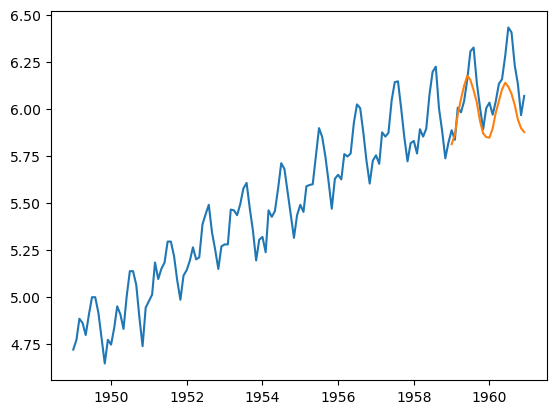

In [108]:
plt.plot(log_df)

In [109]:
# 5,1, 4


from statsmodels.tsa.statespace.sarimax import SARIMAX

In [110]:
sarimax_model = SARIMAX(train , order =(5,1,4), seasonal_order=(5,1,4,12))  #(p,d, q, s)

C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [111]:
sarimax_model = sarimax_model.fit()

C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\LuxLogix Design PC 2\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retva

In [112]:
log_df['Sarimax_prediction'] = sarimax_model.predict(start = len(train), end= len(train)+len(test)-1)

In [113]:
log_df[120:]

,#Passengers,ARIMA Prediction,Sarimax_prediction
Month,,,
1959-01-01,5.886104,5.811950,5.870112
1959-02-01,5.834811,5.861380,5.789659
1959-03-01,6.006353,5.969164,5.957457
1959-04-01,5.981414,6.051946,5.947045
1959-05-01,6.040255,6.122208,5.991146
1959-06-01,6.156979,6.176193,6.135316
1959-07-01,6.306275,6.153700,6.246579
1959-08-01,6.326149,6.098807,6.253417
1959-09-01,6.137727,6.033715,6.081027


<Axes: xlabel='Month'>

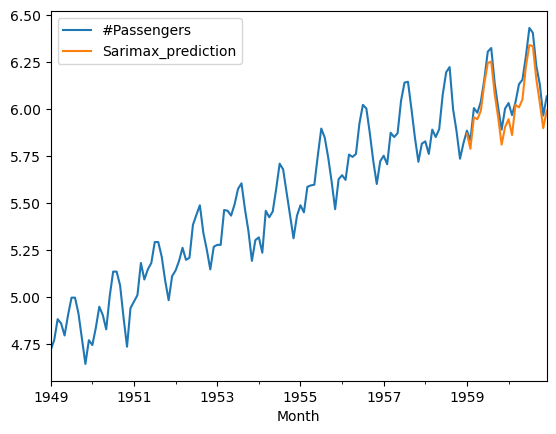

In [114]:
log_df[['#Passengers', 'Sarimax_prediction']].plot()

In [115]:
#forecast

future = sarimax_model.forecast(steps=60) # 5 years

In [117]:
future

1959-01-01    5.870112
1959-02-01    5.789659
1959-03-01    5.957457
1959-04-01    5.947045
1959-05-01    5.991146
1959-06-01    6.135316
1959-07-01    6.246579
1959-08-01    6.253417
1959-09-01    6.081027
1959-10-01    5.955527
1959-11-01    5.811934
1959-12-01    5.905597
1960-01-01    5.947278
1960-02-01    5.862919
1960-03-01    6.023758
1960-04-01    6.009987
1960-05-01    6.052393
1960-06-01    6.227499
1960-07-01    6.341937
1960-08-01    6.335904
1960-09-01    6.160853
1960-10-01    6.035259
1960-11-01    5.899382
1960-12-01    5.993329
1961-01-01    6.033373
1961-02-01    5.951435
1961-03-01    6.110625
1961-04-01    6.107858
1961-05-01    6.138505
1961-06-01    6.311898
1961-07-01    6.434824
1961-08-01    6.424764
1961-09-01    6.250051
1961-10-01    6.115941
1961-11-01    5.971731
1961-12-01    6.071199
1962-01-01    6.105718
1962-02-01    6.019818
1962-03-01    6.175143
1962-04-01    6.166616
1962-05-01    6.201991
1962-06-01    6.384410
1962-07-01    6.503766
1962-08-01 

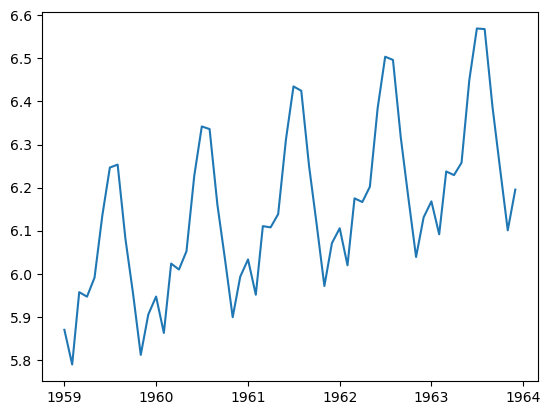

In [116]:
plt.plot(future)

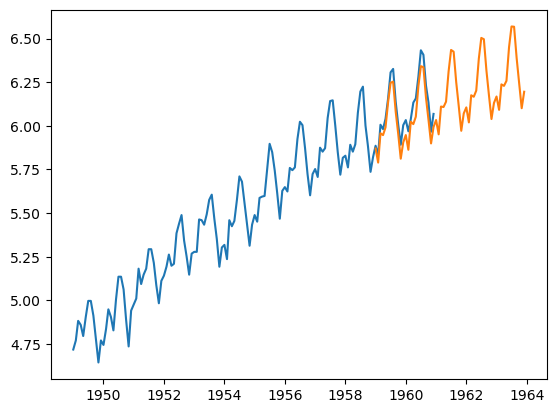

In [120]:
plt.plot(log_df['#Passengers'])
plt.plot(future)

In [121]:
#Steps we do as far

# load the dataset
# make month to datetime datatype
# change the month column to index
# we check for stationarity using seasonal decompse , adfuller
#  performed rolling mean and rolling standard devation
# we performed log transformation
# we performed defferencing only once
# we started model building : train, test
# we pass the training to model using len(train), len(train)+len(test)-1
# randomly we intialized p and q
# we use plot acf and pacf plot to get optimal of p and q
# we use another approach itertools
# based on p, d, q , we got from itertools , we run arima model

# then implemented sarimax and forecast it for next 60 months